# $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

import dependencies

In [1]:
import os
import itertools
import functools


import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np
import tqdm
import networkx as nx
import scipy


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.animation import FFMpegWriter
from jax.extend.backend import get_backend

from opalg import lattice
from opalg import sec_quant

print(jax.devices())

print(f"JAX is using: {get_backend().platform}")

[CudaDevice(id=0)]
JAX is using: gpu


## Utils

In [4]:
def format_size(size_in_bytes):
    """
    Convert a size in bytes to a human-readable string with units B, KB, MB, or GB.

    Args:
        size_in_bytes (int): Size in bytes. Must be non-negative.

    Returns:
        str: Formatted size with appropriate unit.

    Raises:
        ValueError: If size_in_bytes is negative.

    Examples:
        >>> format_size(123)
        '123.00 B'
        >>> format_size(1024)
        '1.00 KB'
        >>> format_size(1048576)
        '1.00 MB'
        >>> format_size(1073741824)
        '1.00 GB'
        >>> format_size(2**40)
        '1024.00 GB'
    """
    if size_in_bytes < 0:
        raise ValueError("Size must be non-negative")

    units = ["B", "KB", "MB", "GB"]
    unit_index = 0

    # Keep dividing by 1024 to find the appropriate unit, but stop at GB
    while size_in_bytes >= 1024 and unit_index < len(units) - 1:
        size_in_bytes /= 1024
        unit_index += 1

    # Format the number to two decimal places
    return f"{size_in_bytes:.2f} {units[unit_index]}"

`get_sites_multi_indices`: Return multi-indices tuple of sites. sorted by lexicographic order.

`get_single_particle_states`: Return single particle states including spin states $\ket{\mathbf{r}_i, 
\sigma}$ as a tuple (site multi-index, $\sigma$). sorted by lexicographic order.

`get_multi_particle_states`: Return combination of single particle states. each state is sorted by lexicographic order $c_{\sigma_1}^\dagger(\mathbf{r}_1)\cdots c_{\sigma_n}^\dagger(\mathbf{r}_N)\ket{0}$

In [5]:
def print_multi_particle_states_info(multi_particle_states):
    num_particles = len(multi_particle_states[0])
    print(f"{len(multi_particle_states)} {num_particles}-particle states")
    print(f"{format_size(len(multi_particle_states) * 16)} per state (complex128)")
    print(f"{format_size((len(multi_particle_states) ** 2) * 16)} for dense representation of an operator (complex128)")

In [6]:
def create_index_map(elements):
    return {element: idx for idx, element in enumerate(elements)}

In [7]:
def order(lhs, rhs):
    site_index1, spin1 = lhs
    site_index2, spin2 = rhs
    
    if site_index1 < site_index2:
        return True
    elif site_index1 == site_index2:
        return spin1 > spin2
    return False

key_func = functools.cmp_to_key(order)

In [8]:
def sorted_multi_particle_state(multi_particle_state):
    """return sorted multi_particle_state as tuple and parity of swap count
    partiy = 1 if sorted list is even permutation of original list.
    parity = -1 if it is odd permutation.
    parity = 0 if it cannot be determined. (there exists a pair of identical element.)
    """
    lst = list(multi_particle_state)
    n_particles = len(lst)
    parity = 1
    for i in range(n_particles):
        swapped = False
        for j in range(0, n_particles - i - 1):
            if lst[j] == lst[j + 1]:
                parity = 0
                continue
            if not order(lst[j], lst[j + 1]):
                lst[j], lst[j + 1] = lst[j + 1], lst[j]
                swapped = True
                parity *= -1
        if not swapped:
            break
    return tuple(lst), parity

In [9]:
lengths = [8,]
n_particle = 4
sites_multi_indices = lattice.multi_indices(lengths)
single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))

print_multi_particle_states_info(multi_particle_states)

1820 4-particle states
28.44 KB per state (complex128)
50.54 MB for dense representation of an operator (complex128)


### Fourier transformations

$$\\\\\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

## Solving ODE

### utils

 ### Defining Operators and Getting Matrix Representation


- hamiltonian

$$
\begin{align}
    H&=\sum_{\mathbf{k}}[t_{\uparrow\uparrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\uparrow\downarrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})+t_{\downarrow\uparrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\downarrow\downarrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})]-i\frac{\gamma}{2}\sum_{\mathbf{r}}n_\uparrow(\mathbf{r}) n_\downarrow(\mathbf{r}) \\
    &=\underbrace{\sum_{\mathbf{k}}\left[\varepsilon_1(\mathbf{k})c_1^\dagger(\mathbf{k})c_1(\mathbf{k}) + \varepsilon_2(\mathbf{k})c_2^\dagger(\mathbf{k})c_2(\mathbf{k})\right]}_{H_0} + \underbrace{\frac{-1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')}_{V_\text{loss}}
\end{align}

$$

$$t_{\uparrow\uparrow}=\frac{\hbar^2(k-q)^2}{2m_\mathrm{Yb}}+\frac{\delta}{2},\quad t_{\uparrow\downarrow}= t_{\downarrow\uparrow}=\frac{\Omega_R}{2},\quad t_{\downarrow\downarrow}=\frac{\hbar^2(k+q)^2}{2m_\mathrm{Yb}}-\frac{\delta}{2}$$

- number operators

$$n_\sigma = c_\sigma^\dagger(\mathbf{k})c_\sigma(\mathbf{k}), \quad \sigma=\uparrow,\downarrow$$
$$n_m = c_m^\dagger(\mathbf{k})c_m(\mathbf{k}), \quad m=1, 2$$

$$
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_1(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & \beta(\mathbf{k}) \\
    -\beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix},\quad
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & -\beta(\mathbf{k}) \\
    \beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_1(\mathbf{k})
\end{pmatrix}
$$
$\alpha$ and $\beta$ are real and $\alpha^2+\beta^2=1$


- fourier transforms

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

lattice parameters

constants

In [ ]:
hbar=1,
q=0.03,
m_Yb = 1,
delta = 0.08,
omega_R = 0.2,
gamma = 0.1,

def trace_e(k):
    return ((hbar ** 2) / (2 * m_Yb)) * ((k - q) ** 2 + (k + q) ** 2)

def delta_e(k):
    return ((hbar ** 2) / (2 * m_Yb)) * ((k - q) ** 2 - (k + q) ** 2) + delta

def e1(k):
    return (trace_e(k) + jnp.sqrt(delta_e(k) ** 2 + omega_R ** 2)) / 2

def e2(k):
    return (trace_e(k) - jnp.sqrt(delta_e(k) ** 2 + omega_R ** 2)) / 2

def theta(k):
    return (1 / 2) * jnp.arctan(omega_R / delta_e(k))

def alpha(k):
    return jnp.cos(theta(k))

def beta(k):
    return jnp.sin(theta(k))

$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [10]:
%load_ext line_profiler

def YbSOCHamiltonian(
    d: float,
    lengths: list[int],
    n_particle: int,
    hbar: float,
    q: list[float] | float,
    m_Yb: float,
    delta: float,
    omega_R: float,
    gamma: float,
    print_info: bool = True,
    display_progress: bool = True
):
    dim = len(lengths)  
    if isinstance(q, float):
        q = [q] * dim
    q = jnp.array(q)
    k0 = 2 * jnp.pi / (d * jnp.array(lengths))
    
    # creating state-flat index map
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))

    num_sites = len(sites_multi_indices)
    num_single_particle_states = len(single_particle_states)
    num_multi_particle_states = len(multi_particle_states)

    site_to_index_map = create_index_map(sites_multi_indices)
    state_to_index_map_single = create_index_map(single_particle_states)
    state_to_index_map_multi = create_index_map(multi_particle_states)

    if print_info:
        print_multi_particle_states_info(multi_particle_states)

    positions = lattice.position_arr(lengths, d)
    momentums = lattice.momentum_arr(lengths, d)

    @jax.jit
    def kinetic(k):
        t = jnp.array([
            [(hbar ** 2) * jnp.sum((k - q) ** 2) / (2 * m_Yb) + delta / 2, omega_R / 2],
            [omega_R / 2, (hbar ** 2) * jnp.sum((k + q) ** 2) / (2 * m_Yb) - delta / 2]
        ])
        return jax.device_put(t, device=jax.devices("cpu")[0])
    
    space_dim = num_multi_particle_states
    hamiltonian = np.zeros((space_dim, space_dim), np.complex128)
    
    # kinetic term


    for state_index, multi_particle_state \
    in tqdm.tqdm(list(enumerate(multi_particle_states))) \
    if display_progress \
    else enumerate(multi_particle_states):
        num_particles = len(multi_particle_state)
        iterator = iter(range(num_particles))
        
        for i in iterator:
            momentum_idx, spin = multi_particle_state[i]
            momentum = momentums[site_to_index_map[momentum_idx]]
            t = np.array(kinetic(momentum))

            if (i + 1 < num_particles) and (momentum_idx == multi_particle_state[i + 1][0]):
                # state contain c_up(k), c_down(k) both
                hamiltonian[state_index, state_index] += t.trace()
                next(iterator, None)
            else:
                # state contain c_up(k) xor c_down(k)
                spin_changed = list(multi_particle_state)   # copy state
                spin_changed[i] = (momentum_idx, -spin)     # reflect spin
                spin_changed_tuple = tuple(spin_changed)
                spin_changed_index = state_to_index_map_multi[spin_changed_tuple]
                
                spin_idx = (1 - spin) // 2  # \sigma = 1 -> 0, \sigma -1 -> 1

                hamiltonian[state_index, state_index] += t[spin_idx, spin_idx]
                hamiltonian[spin_changed_index, state_index] += t[1 - spin_idx, spin_idx]
                   
    # interaction term
    U = -1j * gamma / 2
    for state_index, multi_particle_state \
    in tqdm.tqdm(list(enumerate(multi_particle_states))) \
    if display_progress \
    else enumerate(multi_particle_states):
        spin_up_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == 1]
        spin_down_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == -1]

        for spin_up_state, spin_down_state in itertools.product(spin_up_states, spin_down_states):
            idx1, momentum_1_idx_i = spin_up_state
            idx2, momentum_2_idx_i = spin_down_state

            for q_idx in sites_multi_indices:
                momentum_1_idx_f = lattice.add_multi_indices(momentum_1_idx_i, q_idx, lengths)
                momentum_2_idx_f = lattice.subtract_multi_indices(momentum_2_idx_i, q_idx, lengths)
                new_multi_particle_state = list(multi_particle_state)
                new_multi_particle_state[idx1] = (momentum_1_idx_f, 1)
                new_multi_particle_state[idx2] = (momentum_2_idx_f, -1)
                new_multi_particle_state, parity = sorted_multi_particle_state(new_multi_particle_state)
                if parity == 0:
                    continue
                new_idx = state_to_index_map_multi[new_multi_particle_state]
                hamiltonian[new_idx, state_index] += parity * U / num_sites

    return jnp.array(hamiltonian)

def YbSOCHamiltonian_sparse(
    d: float,
    lengths: list[int],
    n_particle: int,
    hbar: float,
    q: list[float] | float,
    m_Yb: float,
    delta: float,
    omega_R: float,
    gamma: float,
    print_info: bool = True,
    display_progress: bool = True
):
    space_dim = len(multi_partticle_states)
    
    sparse_hamiltonian = scipy.sparse.dok_matrix((space_dim, space_dim), dtype=np.complex128)

    return sparse_hamiltonian

In [11]:
H_dense = YbSOCHamiltonian(
    d=1,
    lengths=[10,],
    n_particle=4,
    hbar=1,
    q=0.03,
    m_Yb = 1,
    delta = 0.08,
    omega_R = 0.2,
    gamma = 0.1,
)

4845 4-particle states
75.70 KB per state (complex128)
358.19 MB for dense representation of an operator (complex128)


100%|██████████| 4845/4845 [00:00<00:00, 15145.75it/s]


### others

$$ n_\uparrow(\mathbf{k}), n_\downarrow(\mathbf{k})

In [150]:
def __number_operator_spin(vec, momentum_index, spin):
    pass

number_operator_spin = {}

$$ n_1(\mathbf{k}), n_2(\mathbf{k})

In [12]:
def __number_operator_1(vec, momentum_index):
    pass

def __number_operator_2(vec, momentum_index):
    pass

number_operator_bare_states = {}

$$\braket{n_\uparrow(\mathbf{k})}, \braket{n_\downarrow(\mathbf{k})}$$

In [13]:
def __number_operator_spin_expectation(vec, momentum_index, spin):
    pass

number_operator_spin_expectation = {}

$$\braket{n_1(\mathbf{k})}, \braket{n_2(\mathbf{k})}$$

In [14]:
def __number_operator_bare_expectation(vec, momentum_index, spin):
    pass

number_operator_bare_expectation = {}

### Setting initial state

$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

In [15]:
# def get_state_vector_from_momentum(single_particle_states):
#     """single particle state |k, s>들을 list of tuple [(i_k, s) ...] 형태로 받아 one-hot vector를 반환합니다. 
#     k는 lattice momentum vector, i_k는 k에 부여된 multi-index s는 Pauli-z operator의 eigenvalue
    
#     Args:
#         single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.

#     Returns:
#         jax.Array: one-hot vector
    
#     """
#     assert len(single_particle_states) == num_particles
#     space_dim = len(multi_particle_states)
#     multi_particle_state, parity = sorted_multi_particle_state(single_particle_states)
#     assert parity != 0
#     idx = state_to_index_map_multi[multi_particle_state]
#     zero_vector = jnp.zeros((space_dim,), dtype=jnp.complex128)
#     one_hot = zero_vector.at(idx).set(parity)
#     return parity * one_hot

# def get_state_vector_from_position(single_particle_states):
#     """single particle state |r_i, s>들을 list of tuple [(i, s) ...] 형태로 받아 하나의 vector를 반환합니다. 
#     i는 multi-index, r_i는 particle의 위치, s는 Pauli-z operator의 eigenvalue
    
#     Args:
#         single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.

#     Returns:
#         jax.Array: one-hot vector
    
#     """
#     space_dim = len(multi_particle_states)
#     zero_vector = np.zeros((space_dim,), dtype=jnp.complex128)
    
#     for permutation in itertools.permutations(len(num_sites), n):
#         pass
    
#     multi_particle_state, parity = sorted_multi_particle_state(single_particle_states)
#     assert parity != 0
#     idx = state_to_index_map_multi[multi_particle_state]
    
#     one_hot = zero_vector.at(idx).set(1)
#     return jnp.array(one_hot)

# def get_bare_state(single_particle_states, state_to_index_map_multi=state_to_index_map_multi, space_dim=len(multi_particle_states)):
#     """single particle state들 |k, m>를 tuple (i_k, m) 형태로 받아 vector를 반환합니다. 
#     k는 lattice momentum vector, i_k는 k에 부여된 multi-index s는 Pauli-z operator의 eigenvalue
    
#     Args:
#         single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.
#         state_to_index_map_multi
#         space_dim

#     Returns:
#         jax.Array: one-hot vector
    
#     """    
#     vector = jnp.zeros((space_dim,))
#     n_particles = len(single_particle_states)
#     z = [1, -1]
#     for zs in itertools.product(z, repeat=n_particles):
#         vector = vector + 0 # TODO: determine the coefficients
        
#     return vector
    
    

### Numerically integrating Schrodinger's equation

$$\frac{d}{dt}\ket{\psi}=-\frac{i}{\hbar}H\ket{\psi}$$

In [151]:
hbar = 1
H_dense = YbSOCHamiltonian(
    d=1,
    lengths=[10,],
    n_particle=4,
    hbar=hbar,
    q=0.03,
    m_Yb = 1,
    delta = 0.08,
    omega_R = 0.2,
    gamma = 0.1,
)

4845 4-particle states
75.70 KB per state (complex128)
358.19 MB for dense representation of an operator (complex128)


100%|██████████| 4845/4845 [00:00<00:00, 15130.49it/s]


In [16]:
# params
t0 = 0
n_steps = 10000
step_size = 1e-4

In [ ]:
def f(vec):
    return -(1j / hbar) * (H_dense @ vec)

# initial_state = 
# solution = odesolver.solve_ivp(f, t0, initial_state, n_steps, step_size=step_size)

### plotting results

## ED

In [12]:
def num_momentum_diag(momentum_multi_index, spin, multi_particle_states):
    # return diagonal elements of momentum-space number operator
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for index, multi_particle_state in enumerate(multi_particle_states):
        if (momentum_multi_index, spin) in multi_particle_state:
            zero_vector[index] = 1
    return jnp.array(zero_vector)
    
def num_cooper_pairs_diag(lengths, n_particle):
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))
    
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for momentum_midx in sites_multi_indices:
        momentum_midx_neg = lattice.negate_multi_index(momentum_midx, lengths)
        n1 = num_momentum_diag(momentum_midx, 1, multi_particle_states)
        n2 = num_momentum_diag(momentum_midx_neg, -1, multi_particle_states)
        zero_vector += n1 * n2
    return jnp.array(zero_vector)

def cooper_pair_corr_diag(lengths, n_particle):
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))
    
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for momentum_midx in sites_multi_indices:
        momentum_midx_op = lattice.negate_multi_index(momentum_midx, lengths)
        n1 = num_momentum_diag(momentum_midx, 1, multi_particle_states)
        n2 = num_momentum_diag(momentum_midx_op, -1, multi_particle_states)
        zero_vector += 1 - n1 - n2 + n1 * n2
    return jnp.array(zero_vector)

def cooper_pair_corr(lengths, n_particle):
    sites_multi_indices = lattice.multi_indices(lengths)
    single_particle_states = list(itertools.product(sites_multi_indices, [1, -1]))
    multi_particle_states = list(itertools.combinations(single_particle_states, n_particle))
    
    num_sites = len(sites_multi_indices)
    num_single_particle_states = len(single_particle_states)
    num_multi_particle_states = len(multi_particle_states)

    site_to_index_map = create_index_map(sites_multi_indices)
    state_to_index_map_single = create_index_map(single_particle_states)
    state_to_index_map_multi = create_index_map(multi_particle_states)

    space_dim = num_multi_particle_states
    
    corr_op = np.zeros((space_dim, space_dim), dtype=np.complex128)
    
    for state_index, multi_particle_state in enumerate(multi_particle_states):
        spin_up_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == 1]
        spin_down_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == -1]
        
        # c^\dagger_\downarrow(q)c^\dagger_\uparrow(q)c_\uparrow(k)c_downarrow(k)
        for spin_up_state in spin_up_states:
            idx1, momentum_midx = spin_up_state
            oppo_midx = lattice.negate_multi_index(momentum_midx, lengths)
            
            # search (oppo_midx, down)
            idx2 = next((t[0] for t in spin_down_states if t[1] == oppo_midx), None)
            
            # if unfound, continue
            if idx2 is None:
                continue
            
            for q_midx in sites_multi_indices:
                q_midx_neg = lattice.negate_multi_index(q_midx, lengths)
                new_multi_particle_state = list(multi_particle_state)
                new_multi_particle_state[idx1] = (q_midx, 1)
                new_multi_particle_state[idx2] = (q_midx_neg, -1)
                new_multi_particle_state, parity = sorted_multi_particle_state(new_multi_particle_state)
                if parity == 0:
                    continue
                new_idx = state_to_index_map_multi[new_multi_particle_state]
                corr_op[new_idx, state_index] += parity
    
    return jnp.array(corr_op)

# from scipy.special import binom

# jnp.sum(num_momentum_diag((0, ), 1)), binom(num_single_particle_states - 1, num_particles - 1)

In [14]:
lengths=[10,]
n_particle=4

H_dense = YbSOCHamiltonian(
    d=1,
    lengths=lengths,
    n_particle=n_particle,
    hbar=1,
    q=0.03,
    m_Yb = 1,
    delta = 0.08,
    omega_R = 0.2,
    gamma = 0.335,
)

4845 4-particle states
75.70 KB per state (complex128)
358.19 MB for dense representation of an operator (complex128)


100%|██████████| 4845/4845 [00:00<00:00, 15381.67it/s]


In [ ]:
eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)

E_r = jnp.real(eigenvalues)
E_i = jnp.imag(eigenvalues)

min_E_r_idx = jnp.argmin(E_r)
min_E_i_idx = jnp.argmin(E_i)

In [16]:
# mcpd = num_cooper_pairs_diag(lengths, n_particle)
# corr = cooper_pair_corr_diag(lengths, n_particle)

# probs = jnp.abs(eigenvectors) ** 2

# nc = jnp.einsum('i,ij->j', mcpd, probs)
# co = jnp.einsum('i,ij->j', corr, probs)

corr_mat = cooper_pair_corr(lengths, n_particle)
co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)

/home/pco0511/.local/lib/python3.12/site-packages/jax/_src/array.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(self._value, dtype=dtype, **kwds)


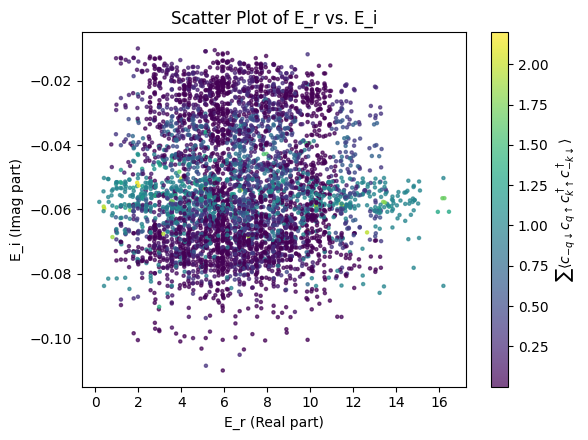

Array(0.0076338-8.13151629e-20j, dtype=complex128)

In [17]:

plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(E_r, E_i, c=co, alpha=0.7, s=5)

cbar = plt.colorbar(scatter)
cbar.set_label('$\\sum\\langle{c_{-q\\downarrow} c_{q\\uparrow}}c_{k\\uparrow}^\\dagger c_{-k\\downarrow}^\\dagger\\rangle$')

plt.xlabel("E_r (Real part)")
plt.ylabel("E_i (Imag part)")
plt.title("Scatter Plot of E_r vs. E_i")

# plt.grid(True)
plt.tight_layout()
plt.show()

co[min_E_i_idx]

In [200]:
N = 51
corr_Er_min = np.empty((N,))
corr_Ei_min = np.empty((N,))

gammas = np.linspace(0, 0.5, N)


for idx, gamma in tqdm.tqdm(enumerate(gammas)):
    H_dense = YbSOCHamiltonian(
        d=1,
        lengths=[8,],
        n_particle=4,
        hbar=1,
        q=0.03,
        m_Yb = 1,
        delta = 0.08,
        omega_R = 0.2,
        gamma = gamma,
        print_info=False,
        display_progress=False
    )
    eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)

    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    min_E_r_idx = jnp.argmin(E_r)
    min_E_i_idx = jnp.argmin(E_i)
    
    corr_mat = cooper_pair_corr([8,], 4)
    co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)
    
    corr_Er_min[idx] = co[min_E_r_idx].astype(jnp.float64)
    corr_Ei_min[idx] = co[min_E_i_idx].astype(jnp.float64)


51it [03:15,  3.82s/it]


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_874212/286344856.py:5: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel("$\\sum_{k, q}\\langle c_{\\downarrow}(-q)c_{\\uparrow}(q)c_{\\uparrow}^\\dagger(k)c_{\\downarrow}^\dagger(-k)\\rangle$")


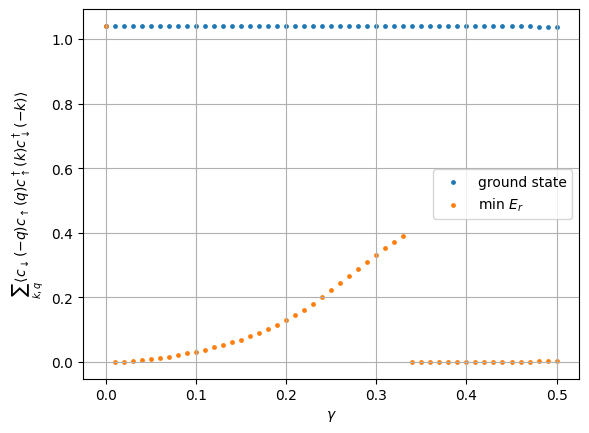

In [211]:
plt.figure()
plt.scatter(gammas, corr_Er_min, label=f"ground state", s=6)
plt.scatter(gammas, corr_Ei_min, label=f"min $E_r$", s=6)
plt.xlabel("$\\gamma$")
plt.ylabel("$\\sum_{k, q}\\langle c_{\\downarrow}(-q)c_{\\uparrow}(q)c_{\\uparrow}^\\dagger(k)c_{\\downarrow}^\dagger(-k)\\rangle$")
plt.legend()
plt.grid()
plt.show()

In [ ]:
N = 51
corr_Er_min = np.empty((7, N))
corr_Ei_min = np.empty((7, N))

gammas = np.linspace(0, 0.5, N)
lengths = [8,]

data_root = r"/home/pco0511/yb-soc-two-body-loss/data/sim2"
os.makedirs(data_root, exist_ok=True)
np.save(
    os.path.join(data_root, "gamma.npy"),
    gammas
)

for n_particle in range(1, 7):
    subdir = os.path.join(data_root, f"dim8_npar{n_particle}_gamma-linsp0-0.5-51")
    os.makedirs(subdir, exist_ok=True)
    for idx, gamma in tqdm.tqdm(enumerate(gammas)):
        H_dense = YbSOCHamiltonian(
            d=1,
            lengths=lengths,
            n_particle=n_particle,
            hbar=1,
            q=0.03,
            m_Yb=1,
            delta=0.08,
            omega_R=0.2,
            gamma=gamma,
            print_info=False,
            display_progress=False
        )
        eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)
        
        np.save(
            os.path.join(subdir, f"eigenvalues_{idx}.npy"),
            eigenvalues
        )
        np.save(
            os.path.join(subdir, f"eigenvectors_{idx}.npy"),
            eigenvectors
        )

        E_r = jnp.real(eigenvalues)
        E_i = jnp.imag(eigenvalues)

        min_E_r_idx = jnp.argmin(E_r)
        min_E_i_idx = jnp.argmin(E_i)


        corr = cooper_pair_corr_diag(lengths, n_particle)
        probs = jnp.abs(eigenvectors) ** 2
        co = jnp.einsum('i,ij->j', corr, probs)

        # corr_mat = cooper_pair_corr(lengths, n_particle)
        # co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)

        corr_Er_min[n_particle-1, idx] = co[min_E_r_idx].astype(jnp.float64)
        corr_Ei_min[n_particle-1, idx] = co[min_E_i_idx].astype(jnp.float64)


51it [00:01, 32.02it/s]
51it [00:03, 14.29it/s]
51it [00:23,  2.14it/s]
51it [03:15,  3.84s/it]
51it [34:32, 40.64s/it]
18it [1:08:23, 235.04s/it]

In [76]:
# np.save("/home/pco0511/yb-soc-two-body-loss/data/temp/gamma.npy", gammas)
np.save("/home/pco0511/yb-soc-two-body-loss/data/sim1/minEr.npy", corr_Er_min)
np.save("/home/pco0511/yb-soc-two-body-loss/data/sim1/minEi.npy", corr_Ei_min)

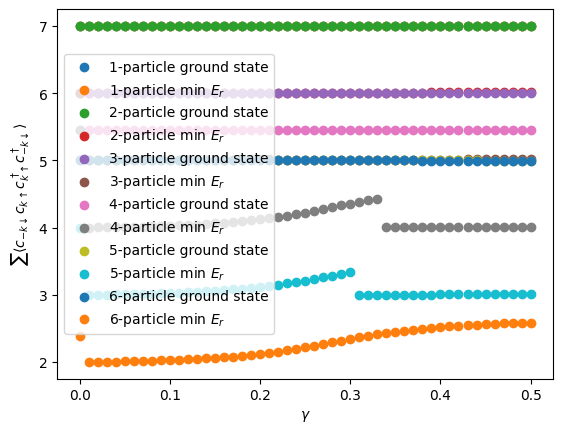

In [ ]:
plt.figure()
for i in range(1, 7):
    plt.scatter(gammas, corr_Er_min[i - 1], label=f"{i}-particle ground state")
    plt.scatter(gammas, corr_Ei_min[i - 1], label=f"{i}-particle min $E_r$")
plt.xlabel("$\\gamma$")
plt.ylabel("\\sum{k, q}\\langle c^\\dagger{\\downarrow}(-q)c^\\dagger{\\uparrow}(q)c{\\uparrow}(k)c_{\\downarrow}(-k)\\rangle")
plt.legend()
plt.show()

In [54]:
gammas

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 ])